In [1]:
import numpy as np
from gsfit_rs import d2_psi_d_z2_py
# from gsfit_rs import d2_psi_d_r2_py
import matplotlib.pyplot as plt
from scipy.constants import mu_0

12
26


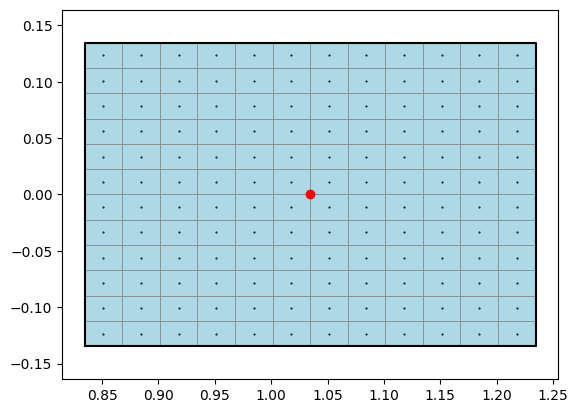

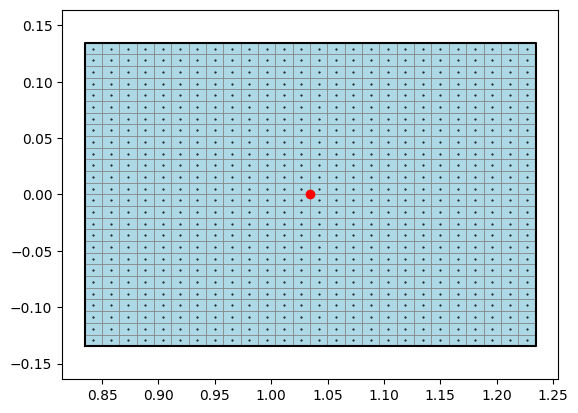

In [2]:
conductor_outline_r_left = 0.8345
conductor_outline_r_right = 1.2345
conductor_outline_z_bottom = -0.13456789
conductor_outline_z_top = 0.13456789
delta_r = (conductor_outline_r_right - conductor_outline_r_left) / 2.0
delta_z = (conductor_outline_z_top - conductor_outline_z_bottom) / 2.0

conductor_outline_r = np.array([conductor_outline_r_left, conductor_outline_r_right, conductor_outline_r_right, conductor_outline_r_left, conductor_outline_r_left], dtype=np.float64)
conductor_outline_z = np.array([conductor_outline_z_bottom, conductor_outline_z_bottom, conductor_outline_z_top, conductor_outline_z_top, conductor_outline_z_bottom], dtype=np.float64)

n_rzs = [12, 26]
g_d2_psi_d_z2_sums = []
for n_rz in n_rzs:
    print(n_rz)
    d_r = (conductor_outline_r_right - conductor_outline_r_left) / n_rz
    d_z = (conductor_outline_z_top - conductor_outline_z_bottom) / n_rz
    r_conductor = np.linspace(conductor_outline_r_left + d_r / 2, conductor_outline_r_right - d_r / 2, n_rz, dtype=np.float64)
    z_conductor = np.linspace(conductor_outline_z_bottom + d_z / 2, conductor_outline_z_top - d_z / 2, n_rz, dtype=np.float64)

    sensor_r = np.array([1.0345], dtype=np.float64)
    sensor_z = np.array([0.0], dtype=np.float64)

    [r_conductor_grid, z_conductor_grid] = np.meshgrid(r_conductor, z_conductor)
    r_conductor_flat = r_conductor_grid.flatten()
    z_conductor_flat = z_conductor_grid.flatten()

    d_r_conductor = np.zeros(n_rz * n_rz, dtype=np.float64)
    d_z_conductor = np.zeros(n_rz * n_rz, dtype=np.float64)

    d_area_conductor = d_r * d_z

    plt.figure()
    plt.axis('equal')
    plt.plot(conductor_outline_r, conductor_outline_z, 'k-', label='Conductor Outline')
    for i in range(len(r_conductor_flat)):
        rect = plt.Rectangle(
            (r_conductor_flat[i] - d_r / 2, z_conductor_flat[i] - d_z / 2),
            d_r, d_z, fill=True, facecolor='lightblue', edgecolor='gray', linewidth=0.5
        )
        plt.gca().add_patch(rect)
    plt.plot(r_conductor_flat, z_conductor_flat, 'k.', markersize=1, label='Conductor')
    plt.plot(sensor_r, sensor_z, 'ro', label='Sensor')

In [3]:
n_rzs = [26, 52, 102, 202, 302, 402, 802, 1602, 2002, 3202]
g_d2_psi_d_z2_sums = []
for n_rz in n_rzs:
    print(n_rz)
    d_r = (conductor_outline_r_right - conductor_outline_r_left) / n_rz
    d_z = (conductor_outline_z_top - conductor_outline_z_bottom) / n_rz
    r_conductor = np.linspace(conductor_outline_r_left + d_r / 2, conductor_outline_r_right - d_r / 2, n_rz, dtype=np.float64)
    z_conductor = np.linspace(conductor_outline_z_bottom + d_z / 2, conductor_outline_z_top - d_z / 2, n_rz, dtype=np.float64)

    r_sensor = np.array([1.0345], dtype=np.float64)
    z_sensor = np.array([0.0], dtype=np.float64)

    [r_conductor_grid, z_conductor_grid] = np.meshgrid(r_conductor, z_conductor)
    r_conductor_flat = r_conductor_grid.flatten()
    z_conductor_flat = z_conductor_grid.flatten()

    d_r_conductor = np.zeros(n_rz * n_rz, dtype=np.float64)
    d_z_conductor = np.zeros(n_rz * n_rz, dtype=np.float64)

    d_area_conductor = d_r * d_z

    g_d2_psi_d_z2 = d2_psi_d_z2_py(r_sensor, z_sensor, r_conductor_flat, z_conductor_flat, d_r_conductor, d_z_conductor)
    g_d2_psi_d_z2_sums.append(float(g_d2_psi_d_z2.sum() * d_area_conductor))

26
52
102
202
302
402
802
1602
2002
3202


In [4]:
# %matplotlib widget

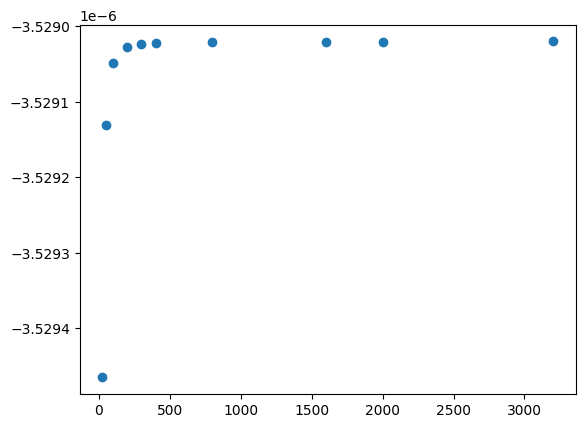

In [5]:
plt.figure()
plt.plot(n_rzs, g_d2_psi_d_z2_sums, 'o')

In [6]:
# Treat the whole conductor as ONE rectangular source with the sensor at its centre.
# NOTE the argument order is (r, z, r_prime, z_prime, d_r, d_z) - the previous version
# of this cell dropped one argument, so r_prime ended up [0.0]: a zero-radius loop on
# the machine axis links no flux, hence the result was exactly 0.0.
# Also: d_r / d_z are the FULL cell width/height, not half-widths.
conductor_r = np.array([(conductor_outline_r_left + conductor_outline_r_right) / 2], dtype=np.float64)
conductor_z = np.array([(conductor_outline_z_bottom + conductor_outline_z_top) / 2], dtype=np.float64)
conductor_d_r = np.array([conductor_outline_r_right - conductor_outline_r_left], dtype=np.float64)
conductor_d_z = np.array([conductor_outline_z_top - conductor_outline_z_bottom], dtype=np.float64)

current = conductor_d_r[0] * conductor_d_z[0]  # J = 1 A/m^2

# Self entry from the Greens table. Beware: this uses the in-a-lattice fraction
# F(lambda) and is the small-cell limit - both assumptions are stretched when the
# whole conductor is a single "cell" with d_r / r ~ 0.4
g_self = d2_psi_d_z2_py(conductor_r, conductor_z, conductor_r, conductor_z, conductor_d_r, conductor_d_z)
one_cell_lattice = float(g_self[0, 0] * current)

# Isolated-rectangle small-cell formula: f_z = (2/pi) * arctan(d_r / d_z), J = 1
one_cell_isolated = float(-4.0 * mu_0 * conductor_r[0] * np.arctan(conductor_d_r[0] / conductor_d_z[0]))

print(f"one cell, lattice F(lambda) self entry:  {one_cell_lattice:.6e}")
print(f"one cell, isolated-rectangle arctan:     {one_cell_isolated:.6e}")

one cell, lattice F(lambda) self entry:  -6.342918e-06
one cell, isolated-rectangle arctan:     -5.088334e-06


In [7]:
# The physical reference value: discretise with ODD n (sensor exactly on the central
# filament) and pass the true cell sizes, which activates the analytic self-term.
# NOTE: a single call with the whole conductor as ONE cell is NOT the physical value -
# that returns the small-cell self entry stretched far beyond its validity
# (the previous cell shows it: -6.34e-6 vs the true -4.93e-6)
n_ref = 401
d_r_ref = (conductor_outline_r_right - conductor_outline_r_left) / n_ref
d_z_ref = (conductor_outline_z_top - conductor_outline_z_bottom) / n_ref
r_conductor_ref = np.linspace(conductor_outline_r_left + d_r_ref / 2, conductor_outline_r_right - d_r_ref / 2, n_ref, dtype=np.float64)
z_conductor_ref = np.linspace(conductor_outline_z_bottom + d_z_ref / 2, conductor_outline_z_top - d_z_ref / 2, n_ref, dtype=np.float64)
[r_grid_ref, z_grid_ref] = np.meshgrid(r_conductor_ref, z_conductor_ref)

g = d2_psi_d_z2_py(
    sensor_r,
    sensor_z,
    r_grid_ref.flatten(),
    z_grid_ref.flatten(),
    np.full(n_ref * n_ref, d_r_ref, dtype=np.float64),
    np.full(n_ref * n_ref, d_z_ref, dtype=np.float64),
)
physical_d2_psi_d_z2 = float(g.sum() * d_r_ref * d_z_ref)
physical_d2_psi_d_z2

-4.9336461466380114e-06

In [8]:
%matplotlib widget

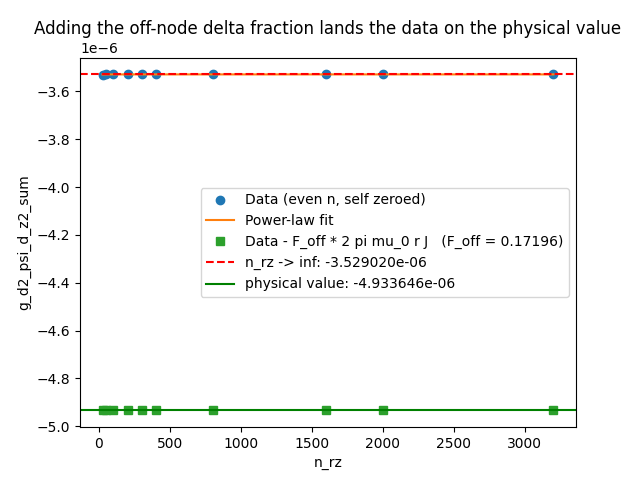

Fit: a * n_rz^(-b) + c
Fit parameters: a=-2.999042e-07, b=1.9994, c=-3.529020e-06
Value at n_rz -> inf:    -3.529020e-06   (off-node lattice principal value)
F_off(lambda=1.48624):  0.171965
Corrected asymptote:     -4.933641e-06
Physical d2_psi_d_z2:    -4.933646e-06
relative difference:     9.47e-07


In [9]:
from scipy.optimize import curve_fit

def power_law(x, a, b, c):
    return a * np.power(x, -b) + c

popt, pcov = curve_fit(power_law, n_rzs, g_d2_psi_d_z2_sums, p0=[1e-5, 2.0, 2e-7])

n_rzs_fine = np.linspace(min(n_rzs), max(n_rzs), 500)
fitted = power_law(n_rzs_fine, *popt)

asymptotic_value = popt[2]

# Delta-function correction for THIS sampling configuration.
# The even-n data has the sensor at a plaquette CENTRE (between filaments), for which
# the fraction of the delta  -2*pi*mu_0*r*J  carried by psi_zz is
#   F_off(lambda) = 1 - (pi/lambda) * sum_{n>=0} sech^2(pi*(n+1/2)/lambda)
# Subtracting the FULL delta would over-correct: psi_zz only carries a fraction of it,
# the remainder belongs to psi_rr (the two fractions sum to 1).
j = 1.0
lam = (conductor_outline_r_right - conductor_outline_r_left) / (conductor_outline_z_top - conductor_outline_z_bottom)  # = d_r/d_z (equal counts in r and z)
f_off = 1.0 - (np.pi / lam) * sum(1.0 / np.cosh(np.pi * (k + 0.5) / lam) ** 2 for k in range(20))
delta_function_correction = 2.0 * np.pi * mu_0 * float(sensor_r[0]) * j * f_off

data = np.array(g_d2_psi_d_z2_sums)

plt.figure()
plt.plot(n_rzs, data, 'o', label='Data (even n, self zeroed)')
plt.plot(n_rzs_fine, fitted, '-', label='Power-law fit')
plt.plot(n_rzs, data - delta_function_correction, 's', label=f'Data - F_off * 2 pi mu_0 r J   (F_off = {f_off:.5f})')
plt.axhline(y=asymptotic_value, color='r', linestyle='--', label=f'n_rz -> inf: {asymptotic_value:.6e}')
plt.axhline(y=physical_d2_psi_d_z2, color='g', linestyle='-', label=f'physical value: {physical_d2_psi_d_z2:.6e}')
plt.xlabel('n_rz')
plt.ylabel('g_d2_psi_d_z2_sum')
plt.title('Adding the off-node delta fraction lands the data on the physical value')
plt.legend()
plt.show()

print(f"Fit: a * n_rz^(-b) + c")
print(f"Fit parameters: a={popt[0]:.6e}, b={popt[1]:.4f}, c={popt[2]:.6e}")
print(f"Value at n_rz -> inf:    {asymptotic_value:.6e}   (off-node lattice principal value)")
print(f"F_off(lambda={lam:.5f}):  {f_off:.6f}")
print(f"Corrected asymptote:     {asymptotic_value - delta_function_correction:.6e}")
print(f"Physical d2_psi_d_z2:    {physical_d2_psi_d_z2:.6e}")
print(f"relative difference:     {abs((asymptotic_value - delta_function_correction) / physical_d2_psi_d_z2 - 1.0):.2e}")

From the convergence we see `b≈2`, i.e. the sum converges — but **to the off-node lattice principal value**, not to the physical $\partial^2\psi/\partial z^2$.

With `d_r_conductor = d_z_conductor = 0` the Greens function has no information about the source size: any coincident filament is zeroed, and the sensor here sits *between* filaments (even `n_rz`), so the sum is missing the delta-function contribution of the Grad–Shafranov equation
$$\Delta^*\psi = -2\pi\mu_0\, r\, J_\phi$$
at the sensor location. The gap between the red and green lines above is exactly that missing contribution — it is $\mathcal{O}(1)$ and no amount of grid refinement recovers it.

The one-cell arctan estimate (treating the whole conductor as a single rectangular cell) lands within ~3% of the physical value; the residual is the $\mathcal{O}(\Delta r / r)$ toroidal-curvature error of the small-cell formula, since here $\Delta r / r \approx 0.4$.

The full derivation is in [`documentation/jump_condition_dbr_dz.md`](../documentation/jump_condition_dbr_dz.md), and the final equation in [`documentation/d2_psi_d_z2_equation.md`](../documentation/d2_psi_d_z2_equation.md).

## The analytic self-term

When the sensor coincides with a source filament of finite size $\Delta r \times \Delta z$ (aspect ratio $\lambda = \Delta r/\Delta z$), the delta-function source splits between $\partial^2\psi/\partial z^2$ and $\partial^2\psi/\partial r^2$. For a filament embedded in a regular lattice (a discretised conductor or the computational grid), the self entry per unit current is

$$
g^{\,\mathrm{self}}_{\psi_{zz}} = -\frac{2\pi\mu_0\, r\, F(\lambda)}{\Delta r\, \Delta z},
\qquad
F(\lambda) = 1 - \frac{\pi}{6\lambda} + \frac{\pi}{\lambda}\sum_{n\ge1}\operatorname{csch}^2\!\left(\frac{\pi n}{\lambda}\right),
\qquad F(\lambda) = 1 - F(1/\lambda) \;\text{ for }\lambda>1 .
$$

$F$ contains both the delta-splitting of an isolated rectangle, $f_z = \tfrac{2}{\pi}\arctan\lambda$, **and** the $\mathcal{O}(1)$ midpoint-quadrature error which the point-filament approximation makes in the neighbouring lattice cells.

This is implemented in `Greens::d2_psi_d_z2` (and the complement $1-F$ in `Greens::d2_psi_d_r2`): passing the true cell sizes through `d_r` / `d_z` activates it. Below we place the sensor **exactly on the central filament** (odd `n_rz`) and check that the corrected sum is grid-independent.

In [11]:
# Sensor exactly ON the central filament (odd n_rz), cell sizes passed -> self-term active
# (sensor defined locally: an earlier cell overwrites r_sensor/z_sensor)
r_sensor_ref = np.array([(conductor_outline_r_left + conductor_outline_r_right) / 2], dtype=np.float64)
z_sensor_ref = np.array([(conductor_outline_z_bottom + conductor_outline_z_top) / 2], dtype=np.float64)

n_rzs_odd = [51, 101, 201, 401, 801]
corrected_sums = []
for n_rz in n_rzs_odd:
    d_r = (conductor_outline_r_right - conductor_outline_r_left) / n_rz
    d_z = (conductor_outline_z_top - conductor_outline_z_bottom) / n_rz
    r_conductor = np.linspace(conductor_outline_r_left + d_r / 2, conductor_outline_r_right - d_r / 2, n_rz, dtype=np.float64)
    z_conductor = np.linspace(conductor_outline_z_bottom + d_z / 2, conductor_outline_z_top - d_z / 2, n_rz, dtype=np.float64)

    [r_conductor_grid, z_conductor_grid] = np.meshgrid(r_conductor, z_conductor)
    r_conductor_flat = r_conductor_grid.flatten()
    z_conductor_flat = z_conductor_grid.flatten()

    d_r_conductor = np.full(n_rz * n_rz, d_r, dtype=np.float64)
    d_z_conductor = np.full(n_rz * n_rz, d_z, dtype=np.float64)

    g_d2_psi_d_z2 = d2_psi_d_z2_py(r_sensor_ref, z_sensor_ref, r_conductor_flat, z_conductor_flat, d_r_conductor, d_z_conductor)
    corrected_sums.append(float(g_d2_psi_d_z2.sum() * d_r * d_z))

for n_rz, value in zip(n_rzs_odd, corrected_sums):
    print(f"n_rz = {n_rz:4d}:  d2_psi_d_z2 = {value:.6e}")

n_rz =   51:  d2_psi_d_z2 = -4.933891e-06
n_rz =  101:  d2_psi_d_z2 = -4.933708e-06
n_rz =  201:  d2_psi_d_z2 = -4.933659e-06
n_rz =  401:  d2_psi_d_z2 = -4.933646e-06
n_rz =  801:  d2_psi_d_z2 = -4.933643e-06


In [12]:
# Independent reference: Richardson-extrapolated second difference of psi.
# The FD offsets are exact multiples of d_z, so every evaluation point sits on a
# filament node where psi uses its (finite) self-inductance expression.
from gsfit_rs import greens_py

n_rz = 801
d_r = (conductor_outline_r_right - conductor_outline_r_left) / n_rz
d_z = (conductor_outline_z_top - conductor_outline_z_bottom) / n_rz
r_conductor = np.linspace(conductor_outline_r_left + d_r / 2, conductor_outline_r_right - d_r / 2, n_rz, dtype=np.float64)
z_conductor = np.linspace(conductor_outline_z_bottom + d_z / 2, conductor_outline_z_top - d_z / 2, n_rz, dtype=np.float64)
[r_conductor_grid, z_conductor_grid] = np.meshgrid(r_conductor, z_conductor)
r_conductor_flat = r_conductor_grid.flatten()
z_conductor_flat = z_conductor_grid.flatten()
d_r_conductor = np.full(n_rz * n_rz, d_r, dtype=np.float64)
d_z_conductor = np.full(n_rz * n_rz, d_z, dtype=np.float64)

delta = 64.0 * d_z
z_eval = np.array([z_sensor_ref[0] - 2 * delta, z_sensor_ref[0] - delta, z_sensor_ref[0], z_sensor_ref[0] + delta, z_sensor_ref[0] + 2 * delta])
r_eval = np.full(5, r_sensor_ref[0])
g_psi = greens_py(r_eval, z_eval, r_conductor_flat, z_conductor_flat, d_r_conductor, d_z_conductor)
psi = g_psi.sum(axis=1) * d_r * d_z  # J = 1 A/m^2

fd_1 = (psi[1] - 2.0 * psi[2] + psi[3]) / delta**2
fd_2 = (psi[0] - 2.0 * psi[2] + psi[4]) / (2.0 * delta) ** 2
d2_psi_d_z2_numerical = (4.0 * fd_1 - fd_2) / 3.0  # Richardson extrapolation

print(f"finite difference of psi:  {d2_psi_d_z2_numerical:.6e}")
print(f"corrected Greens sum:      {corrected_sums[-1]:.6e}")
print(f"relative difference:       {abs(corrected_sums[-1] / d2_psi_d_z2_numerical - 1.0):.2e}")

finite difference of psi:  -4.933657e-06
corrected Greens sum:      -4.933643e-06
relative difference:       2.88e-06


In [13]:
# Robustness: different cell aspect ratios (n_r != n_z) change both the lattice
# principal value AND the self-term, but their sum must be invariant
for n_r, n_z in [(101, 101), (101, 201), (201, 101), (75, 301)]:
    d_r = (conductor_outline_r_right - conductor_outline_r_left) / n_r
    d_z = (conductor_outline_z_top - conductor_outline_z_bottom) / n_z
    r_conductor = np.linspace(conductor_outline_r_left + d_r / 2, conductor_outline_r_right - d_r / 2, n_r, dtype=np.float64)
    z_conductor = np.linspace(conductor_outline_z_bottom + d_z / 2, conductor_outline_z_top - d_z / 2, n_z, dtype=np.float64)

    [r_conductor_grid, z_conductor_grid] = np.meshgrid(r_conductor, z_conductor)
    r_conductor_flat = r_conductor_grid.flatten()
    z_conductor_flat = z_conductor_grid.flatten()

    d_r_conductor = np.full(n_r * n_z, d_r, dtype=np.float64)
    d_z_conductor = np.full(n_r * n_z, d_z, dtype=np.float64)

    g_d2_psi_d_z2 = d2_psi_d_z2_py(r_sensor_ref, z_sensor_ref, r_conductor_flat, z_conductor_flat, d_r_conductor, d_z_conductor)
    total = float(g_d2_psi_d_z2.sum() * d_r * d_z)
    print(f"n_r = {n_r:3d}, n_z = {n_z:3d}, cell aspect d_r/d_z = {d_r / d_z:5.3f}:  d2_psi_d_z2 = {total:.6e}")

n_r = 101, n_z = 101, cell aspect d_r/d_z = 1.486:  d2_psi_d_z2 = -4.933708e-06
n_r = 101, n_z = 201, cell aspect d_r/d_z = 2.958:  d2_psi_d_z2 = -4.933710e-06
n_r = 201, n_z = 101, cell aspect d_r/d_z = 0.747:  d2_psi_d_z2 = -4.933648e-06
n_r =  75, n_z = 301, cell aspect d_r/d_z = 5.965:  d2_psi_d_z2 = -4.933756e-06


### Conclusions

* With the self-term active the Greens-table sum is **grid-independent** and agrees with the finite-difference reference (and with an independent adaptive PV quadrature, $-4.93365\times10^{-6}$) to a few parts in $10^{5}$.
* The result is independent of the cell aspect ratio — the lattice principal value and the self-term $F(\lambda)$ change individually, but their sum is invariant, confirming the splitting formula.
* The mixed derivative `d2_psi_d_r_d_z` needs no self-term (odd symmetry), and `d2_psi_d_r2` carries the complement $1 - F(\lambda)$ so that the pair integrates the Grad–Shafranov delta function exactly.